# Analisis Exploratorio de Datos — Assessment Radmedis

**Fecha:** 2026-03-10  
**Autor:** Farid Sayago  
**Objetivo:** Explorar la base de datos de pagos de 10 clientes para identificar patrones de morosidad, distribucion de montos y comportamiento temporal de pagos.

**Tecnologias utilizadas:**
- Python 3.12
- pandas — manipulacion y transformacion de datos
- seaborn / matplotlib — visualizacion
- openpyxl — lectura/escritura de archivos Excel
- Jupyter Lab — entorno interactivo de analisis

---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Configuracion de visualizacion
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Rutas
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Carga de datos
df = pd.read_excel(DATA_DIR / 'Assessment_AnalistaDatos_Ejercicio.xlsx', sheet_name='Base de Datos')
print('Dataset cargado correctamente.')
print(f'Registros: {len(df)} | Columnas: {len(df.columns)}')

Dataset cargado correctamente.
Registros: 10 | Columnas: 4


## 1. Inspeccion Inicial

In [2]:
print('=== Shape ===')
print(df.shape)

print('\n=== Tipos de datos ===')
print(df.dtypes)

print('\n=== Primeras filas ===')
df.head(10)

=== Shape ===
(10, 4)

=== Tipos de datos ===
ID Cliente                  str
Nombre                      str
Fecha de Pago    datetime64[us]
Monto Pagado              int64
dtype: object

=== Primeras filas ===


,ID Cliente,Nombre,Fecha de Pago,Monto Pagado
0,C001,Juan Pérez,NaT,0
1,C002,María Gómez,2024-02-20,100000
2,C003,Carlos López,2024-03-09,50000
3,C004,Ana Díaz,NaT,250000
4,C005,Luis Torres,2024-05-26,50000
5,C006,Lucía Ramírez,NaT,0
6,C007,Andrés Martínez,NaT,100000
7,C008,Paola Mejía,2024-08-28,250000
8,C009,Pedro Ríos,NaT,250000
9,C010,Laura Sánchez,2024-10-04,50000


In [3]:
print('=== Info general ===')
df.info()

print('\n=== Estadisticas descriptivas ===')
df.describe(include='all')

=== Info general ===
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID Cliente     10 non-null     str           
 1   Nombre         10 non-null     str           
 2   Fecha de Pago  5 non-null      datetime64[us]
 3   Monto Pagado   10 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 452.0 bytes

=== Estadisticas descriptivas ===


,ID Cliente,Nombre,Fecha de Pago,Monto Pagado
count,10,10,5,10.000000
unique,10,10,NaN,NaN
top,C001,Juan Pérez,NaN,NaN
freq,1,1,NaN,NaN
mean,NaN,NaN,2024-06-05 04:48:00,110000.000000
min,NaN,NaN,2024-02-20 00:00:00,0.000000
25%,NaN,NaN,2024-03-09 00:00:00,50000.000000
50%,NaN,NaN,2024-05-26 00:00:00,75000.000000
75%,NaN,NaN,2024-08-28 00:00:00,212500.000000
max,NaN,NaN,2024-10-04 00:00:00,250000.000000


## 2. Analisis de Nulos

In [4]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos
})

print('=== Valores nulos por columna ===')
print(resumen_nulos)
print()
print('Observacion: La columna Fecha de Pago presenta 5 registros nulos (50% del dataset).')
print('Esto indica que 5 clientes no tienen fecha de pago registrada.')

=== Valores nulos por columna ===
               Nulos  Porcentaje (%)
ID Cliente         0             0.0
Nombre             0             0.0
Fecha de Pago      5            50.0
Monto Pagado       0             0.0

Observacion: La columna Fecha de Pago presenta 5 registros nulos (50% del dataset).
Esto indica que 5 clientes no tienen fecha de pago registrada.


## 3. Asunciones Documentadas

Antes de proceder con el analisis, se documentan las asunciones que guian las definiciones analiticas:

**Mora / Default:**
- Un cliente se considera en mora si **no tiene fecha de pago registrada (NaT) Y el monto pagado es igual a 0**.
- Clientes en mora: `C001 - Juan Perez`, `C006 - Lucia Ramirez`.
- Clientes con monto pagado pero sin fecha confirmada (`C004`, `C007`, `C009`) se clasifican como **pago sin fecha confirmada**, no como morosos.

**Recuperacion:**
- El dataset no incluye la deuda original por cliente.
- Se utiliza **250,000 por cliente como proxy de deuda** (total esperado: 2,500,000).
- El porcentaje de recuperacion calculado es una **aproximacion** y debe interpretarse con cautela hasta contar con la deuda real.

**Desglose mensual:**
- Solo se incluyen los meses con pagos efectivamente registrados (febrero, marzo, mayo, agosto, octubre 2024).
- No se rellenan con ceros los meses sin actividad.

## 4. Limpieza y Validacion

In [5]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')

# Verificar unicidad de ID Cliente
ids_unicos = df['ID Cliente'].nunique()
print(f'IDs unicos: {ids_unicos} de {len(df)} registros')

# Validar rango de Monto Pagado
print(f'\nMonto Pagado - Min: {df["Monto Pagado"].min():,} | Max: {df["Monto Pagado"].max():,}')
print(f'Montos negativos: {(df["Monto Pagado"] < 0).sum()}')

# Verificar nombres (sin errores tipograficos detectados)
print(f'\nClientes registrados:')
for _, row in df.iterrows():
    print(f'  {row["ID Cliente"]} - {row["Nombre"]}')

Registros duplicados: 0
IDs unicos: 10 de 10 registros

Monto Pagado - Min: 0 | Max: 250,000
Montos negativos: 0

Clientes registrados:
  C001 - Juan Pérez
  C002 - María Gómez
  C003 - Carlos López
  C004 - Ana Díaz
  C005 - Luis Torres
  C006 - Lucía Ramírez
  C007 - Andrés Martínez
  C008 - Paola Mejía
  C009 - Pedro Ríos
  C010 - Laura Sánchez


In [6]:
# Clasificacion de clientes
def clasificar_cliente(row):
    if pd.isna(row['Fecha de Pago']) and row['Monto Pagado'] == 0:
        return 'En mora'
    elif pd.isna(row['Fecha de Pago']) and row['Monto Pagado'] > 0:
        return 'Pago sin fecha'
    else:
        return 'Pagado con fecha'

df['Estado'] = df.apply(clasificar_cliente, axis=1)

print('=== Clasificacion de clientes ===')
print(df[['ID Cliente', 'Nombre', 'Fecha de Pago', 'Monto Pagado', 'Estado']].to_string(index=False))

=== Clasificacion de clientes ===
ID Cliente          Nombre Fecha de Pago  Monto Pagado           Estado
      C001      Juan Pérez           NaT             0          En mora
      C002     María Gómez    2024-02-20        100000 Pagado con fecha
      C003    Carlos López    2024-03-09         50000 Pagado con fecha
      C004        Ana Díaz           NaT        250000   Pago sin fecha
      C005     Luis Torres    2024-05-26         50000 Pagado con fecha
      C006   Lucía Ramírez           NaT             0          En mora
      C007 Andrés Martínez           NaT        100000   Pago sin fecha
      C008     Paola Mejía    2024-08-28        250000 Pagado con fecha
      C009      Pedro Ríos           NaT        250000   Pago sin fecha
      C010   Laura Sánchez    2024-10-04         50000 Pagado con fecha


## 5. Distribucion de Montos

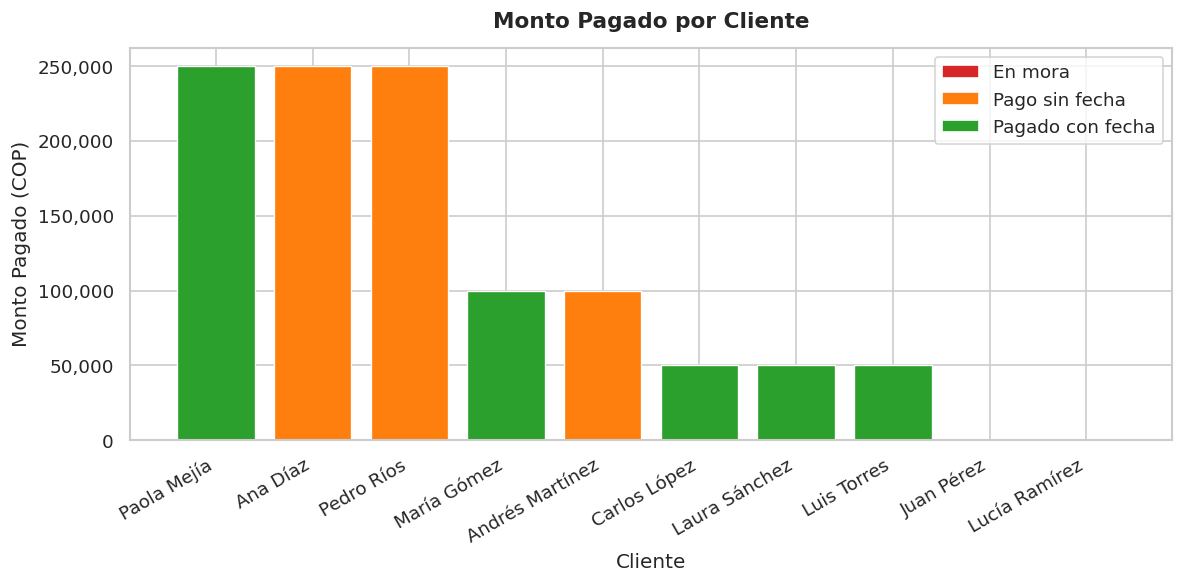

Grafico guardado en outputs/distribucion_montos.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = {'En mora': '#d62728', 'Pago sin fecha': '#ff7f0e', 'Pagado con fecha': '#2ca02c'}
df_sorted = df.sort_values('Monto Pagado', ascending=False)

bars = ax.bar(
    df_sorted['Nombre'],
    df_sorted['Monto Pagado'],
    color=[colores[e] for e in df_sorted['Estado']],
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Monto Pagado por Cliente', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cliente')
ax.set_ylabel('Monto Pagado (COP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30, ha='right')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colores.items()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_montos.png', bbox_inches='tight')
plt.show()
print('Grafico guardado en outputs/distribucion_montos.png')

## 6. Segmentacion de Clientes

=== Segmentacion por estado de pago ===
                  Clientes  Monto Total  % Clientes  % Monto
Estado                                                      
En mora                  2            0        20.0      0.0
Pagado con fecha         5       500000        50.0     45.5
Pago sin fecha           3       600000        30.0     54.5


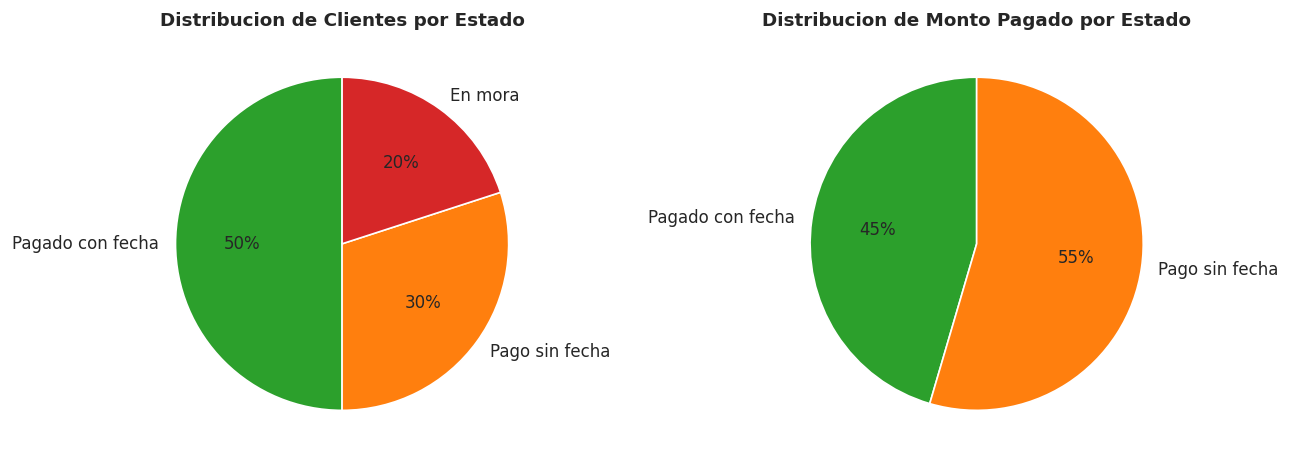

In [8]:
# Conteo por estado
conteo_estado = df['Estado'].value_counts()
monto_por_estado = df.groupby('Estado')['Monto Pagado'].sum()

resumen_estado = pd.DataFrame({
    'Clientes': conteo_estado,
    'Monto Total': monto_por_estado
})
resumen_estado['% Clientes'] = (resumen_estado['Clientes'] / len(df) * 100).round(1)
resumen_estado['% Monto'] = (resumen_estado['Monto Total'] / df['Monto Pagado'].sum() * 100).round(1)

print('=== Segmentacion por estado de pago ===')
print(resumen_estado.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colores_list = [colores[e] for e in conteo_estado.index]

axes[0].pie(conteo_estado, labels=conteo_estado.index, autopct='%1.0f%%',
            colors=colores_list, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Distribucion de Clientes por Estado', fontsize=11, fontweight='bold')

axes[1].pie(monto_por_estado[monto_por_estado > 0], labels=monto_por_estado[monto_por_estado > 0].index,
            autopct='%1.0f%%', colors=[colores[e] for e in monto_por_estado[monto_por_estado > 0].index],
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Distribucion de Monto Pagado por Estado', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segmentacion_clientes.png', bbox_inches='tight')
plt.show()

## 7. Timeline de Pagos por Mes

=== Pagos por mes (solo meses con datos) ===
    Mes  Clientes  Monto_Total
2024-02         1       100000
2024-03         1        50000
2024-05         1        50000
2024-08         1       250000
2024-10         1        50000


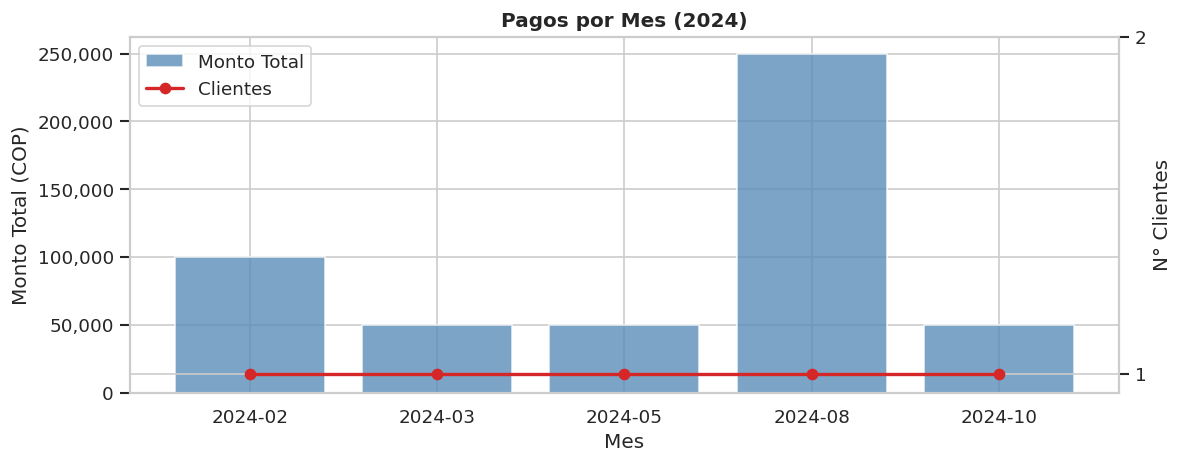

In [9]:
# Solo clientes con fecha de pago registrada
df_con_fecha = df.dropna(subset=['Fecha de Pago']).copy()
df_con_fecha['Mes'] = df_con_fecha['Fecha de Pago'].dt.to_period('M').astype(str)

pagos_mes = df_con_fecha.groupby('Mes').agg(
    Clientes=('ID Cliente', 'count'),
    Monto_Total=('Monto Pagado', 'sum')
).reset_index()

print('=== Pagos por mes (solo meses con datos) ===')
print(pagos_mes.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(pagos_mes['Mes'], pagos_mes['Monto_Total'], color='#5b8db8', alpha=0.8, label='Monto Total')
ax1.set_ylabel('Monto Total (COP)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(pagos_mes['Mes'], pagos_mes['Clientes'], color='#d62728', marker='o', linewidth=2, label='Clientes')
ax2.set_ylabel('N° Clientes')
ax2.set_yticks([1, 2])

ax1.set_title('Pagos por Mes (2024)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mes')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'timeline_pagos.png', bbox_inches='tight')
plt.show()

## 8. Hallazgos Clave

In [10]:
total_recaudado = df['Monto Pagado'].sum()
deuda_proxy = 2_500_000
pct_recuperacion = total_recaudado / deuda_proxy * 100

morosos = df[df['Estado'] == 'En mora'][['ID Cliente', 'Nombre']]
sin_fecha = df[df['Estado'] == 'Pago sin fecha'][['ID Cliente', 'Nombre', 'Monto Pagado']]

print('=' * 55)
print('RESUMEN DE HALLAZGOS')
print('=' * 55)
print(f'Total clientes analizados      : {len(df)}')
print(f'Total recaudado                : {total_recaudado:>12,.0f} COP')
print(f'Deuda proxy (250k x cliente)   : {deuda_proxy:>12,.0f} COP')
print(f'% Recuperacion (aprox.)        : {pct_recuperacion:>11.1f}%')
print()
print(f'Clientes en mora ({len(morosos)}):')
for _, r in morosos.iterrows():
    print(f'  - {r["ID Cliente"]} {r["Nombre"]}')
print()
print(f'Clientes con pago sin fecha ({len(sin_fecha)}):')
for _, r in sin_fecha.iterrows():
    print(f'  - {r["ID Cliente"]} {r["Nombre"]:20s} | {r["Monto Pagado"]:>8,.0f} COP')
print()
print('Meses con pagos registrados    : Feb, Mar, May, Ago, Oct 2024')
print('Mes de mayor recaudacion       : Ago 2024 (250,000 COP — Paola Mejia)')
print()
print('NOTA: El % de recuperacion es aproximado. Requiere deuda original real.')

RESUMEN DE HALLAZGOS
Total clientes analizados      : 10
Total recaudado                :    1,100,000 COP
Deuda proxy (250k x cliente)   :    2,500,000 COP
% Recuperacion (aprox.)        :        44.0%

Clientes en mora (2):
  - C001 Juan Pérez
  - C006 Lucía Ramírez

Clientes con pago sin fecha (3):
  - C004 Ana Díaz             |  250,000 COP
  - C007 Andrés Martínez      |  100,000 COP
  - C009 Pedro Ríos           |  250,000 COP

Meses con pagos registrados    : Feb, Mar, May, Ago, Oct 2024
Mes de mayor recaudacion       : Ago 2024 (250,000 COP — Paola Mejia)

NOTA: El % de recuperacion es aproximado. Requiere deuda original real.
